# step by step, curve analysis 
splitting data step by step --> into segments to analyze by 

In [33]:
import pandas as pd
import numpy as np
from scipy.signal import find_peaks

In [22]:
df = pd.read_csv("data_Cleaned/all_data.csv", low_memory=False)

sensor_cols = [c for c in df.columns if c.startswith("pressure_")]

for c in sensor_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)

In [18]:
df

,sole_id,timestamp,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z,pressure_01,pressure_02,...,time_elapsed,magn_x,magn_y,magn_z,corrupt,total_pressure,frame_peak_pressure,time_s,total_pressure_smooth,step_id
0,1,1768508082448,-646,531,9968,0,-81855,15882,309,183,...,0.000,NaN,NaN,NaN,NaN,3658,469,0.000,3513.500000,1
1,1,1768508082464,-650,540,9973,8552,-87964,14660,309,186,...,0.016,NaN,NaN,NaN,NaN,3591,460,0.016,3504.666667,1
2,1,1768508082480,-636,531,9973,13439,-89186,15882,307,179,...,0.032,NaN,NaN,NaN,NaN,3542,456,0.032,3496.200000,1
3,1,1768508082496,-636,531,9968,14660,-90408,18325,305,182,...,0.048,NaN,NaN,NaN,NaN,3494,456,0.048,3489.272727,1
4,1,1768508082512,-646,536,9968,13439,-90408,19547,302,182,...,0.064,NaN,NaN,NaN,NaN,3518,459,0.064,3483.416667,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43114,2,1768508870896,181,239,9719,68416,102625,-34208,240,202,...,NaN,0.0,0.0,0.0,0.0,3164,417,788.448,3140.916667,603
43115,2,1768508870912,382,157,9858,8552,91629,-7330,238,211,...,NaN,0.0,0.0,0.0,0.0,3202,423,788.464,3189.454545,603
43116,2,1768508870928,315,339,9911,-59864,42760,19547,239,216,...,NaN,0.0,0.0,0.0,0.0,3342,437,788.480,3225.000000,603
43117,2,1768508870944,354,296,9858,-120951,35430,8552,246,229,...,NaN,0.0,0.0,0.0,0.0,3528,444,788.496,3259.222222,603


In [23]:
df["total_pressure"] = df[sensor_cols].sum(axis=1)
df["frame_peak_pressure"] = df[sensor_cols].max(axis=1)

# optional: elapsed time in seconds if timestamp exists
if "timestamp" in df.columns:
    df["time_s"] = (df["timestamp"] - df["timestamp"].iloc[0]) / 1000.0
else:
    df["time_s"] = np.arange(len(df))

In [24]:
# set rolling window 
window = 15
df["total_pressure_smooth"] = (
    df["total_pressure"]
    .rolling(window=window, center=True, min_periods=1)
    .mean()
)

y = df["total_pressure_smooth"].to_numpy()

In [25]:
peaks, peak_props = find_peaks(
    y,
    distance=20,
    prominence=100
)

print(f"Detected {len(peaks)} candidate steps")


Detected 603 candidate steps


In [26]:
boundaries = [0]

for i in range(len(peaks) - 1):
    left_peak = peaks[i]
    right_peak = peaks[i + 1]

    # valley = lowest point between consecutive peaks
    valley_rel = np.argmin(y[left_peak:right_peak + 1])
    valley_idx = left_peak + valley_rel
    boundaries.append(valley_idx)

boundaries.append(len(df) - 1)
boundaries = sorted(boundaries)

In [27]:
df["step_id"] = np.nan

for step_num in range(len(boundaries) - 1):
    start = boundaries[step_num]
    end = boundaries[step_num + 1]

    # include rows from start to end
    df.loc[start:end, "step_id"] = step_num + 1

df["step_id"] = df["step_id"].astype("Int64")

In [28]:
step_summary = []

for step_id, group in df.groupby("step_id"):
    step_summary.append({
        "step_id": step_id,
        "start_index": group.index.min(),
        "end_index": group.index.max(),
        "n_frames": len(group),
        "start_time_s": group["time_s"].iloc[0],
        "end_time_s": group["time_s"].iloc[-1],
        "duration_s": group["time_s"].iloc[-1] - group["time_s"].iloc[0],
        "step_peak_total_pressure": group["total_pressure"].max(),
        "step_mean_total_pressure": group["total_pressure"].mean(),
        "step_peak_sensor_pressure": group["frame_peak_pressure"].max(),
        "ground_type": group["ground_type"].mode().iloc[0] if "ground_type" in group.columns and not group["ground_type"].mode().empty else None
    })

step_df = pd.DataFrame(step_summary)


In [29]:
step_df = step_df[step_df["n_frames"] >= 5].copy()

valid_steps = step_df["step_id"].tolist()
df_segmented = df[df["step_id"].isin(valid_steps)].copy()

# renumber step ids cleanly
step_id_map = {old: new for new, old in enumerate(sorted(valid_steps), start=1)}
df_segmented["step_id"] = df_segmented["step_id"].map(step_id_map)

step_df["step_id"] = step_df["step_id"].map(step_id_map)
step_df = step_df.sort_values("step_id").reset_index(drop=True)

In [30]:
df_segmented.to_csv("all_data_with_step_ids.csv", index=False)
#step_df.to_csv("step_df.csv", index=False)

print(f"\nFinal number of kept steps: {step_df['step_id'].nunique()}")
step_df


Final number of kept steps: 603


,step_id,start_index,end_index,n_frames,start_time_s,end_time_s,duration_s,step_peak_total_pressure,step_mean_total_pressure,step_peak_sensor_pressure,ground_type
0,1,0,47,48,0.000,0.752,0.752,3789,3486.833333,536,asphalt
1,2,48,82,35,0.768,1.312,0.544,3990,3710.742857,553,asphalt
2,3,83,174,92,1.328,2.784,1.456,4105,3903.554348,550,asphalt
3,4,175,251,77,2.800,4.016,1.216,4135,3899.571429,558,asphalt
4,5,252,291,40,4.032,4.656,0.624,3946,3863.275000,515,asphalt
...,...,...,...,...,...,...,...,...,...,...,...
598,599,42414,42531,118,777.248,779.120,1.872,4566,3065.677966,583,None
599,600,42532,42649,118,779.136,781.008,1.872,4160,3292.000000,592,None
600,601,42650,42804,155,781.024,783.488,2.464,4141,3882.393548,488,None
601,602,42805,42945,141,783.504,785.744,2.240,4212,3509.872340,491,None


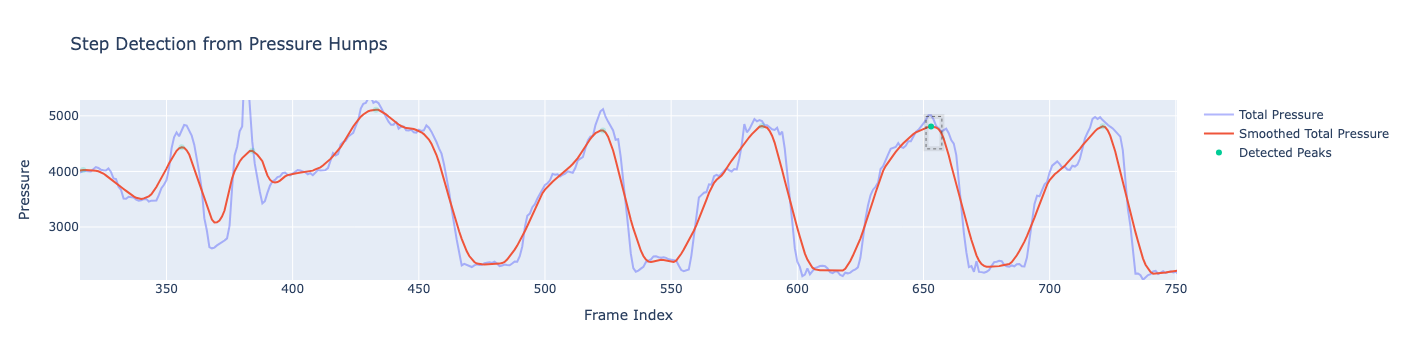

In [19]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df.index,
    y=df["total_pressure"],
    mode="lines",
    name="Total Pressure",
    opacity=0.5
))

fig.add_trace(go.Scatter(
    x=df.index,
    y=df["total_pressure_smooth"],
    mode="lines",
    name="Smoothed Total Pressure"
))

fig.add_trace(go.Scatter(
    x=peaks,
    y=df.loc[peaks, "total_pressure_smooth"],
    mode="markers",
    name="Detected Peaks"
))

fig.update_layout(
    title="Step Detection from Pressure Humps",
    xaxis_title="Frame Index",
    yaxis_title="Pressure"
)

fig.show()

In [31]:
steps = {
    int(step_id): group.reset_index(drop=True).copy()
    for step_id, group in df_segmented.groupby("step_id")
}

In [32]:
print(steps[1].head())
print(steps[1].columns)

   sole_id      timestamp  accel_x  accel_y  accel_z  gyro_x  gyro_y  gyro_z  \
0        1  1768508082448     -646      531     9968       0  -81855   15882   
1        1  1768508082464     -650      540     9973    8552  -87964   14660   
2        1  1768508082480     -636      531     9973   13439  -89186   15882   
3        1  1768508082496     -636      531     9968   14660  -90408   18325   
4        1  1768508082512     -646      536     9968   13439  -90408   19547   

   pressure_01  pressure_02  ...  time_elapsed  magn_x  magn_y  magn_z  \
0          309          183  ...         0.000     NaN     NaN     NaN   
1          309          186  ...         0.016     NaN     NaN     NaN   
2          307          179  ...         0.032     NaN     NaN     NaN   
3          305          182  ...         0.048     NaN     NaN     NaN   
4          302          182  ...         0.064     NaN     NaN     NaN   

   corrupt  total_pressure  frame_peak_pressure  time_s  \
0      NaN     